In [1]:
import torch
print("Is GPU available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Is GPU available? True
GPU Name: Tesla T4


In [2]:
!pip install transformers[torch] datasets accelerate scikit-learn pandas

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

#loading dataset
df = pd.read_csv('deceptive-opinion.csv')


print("Original Columns:", df.columns)

#creating a binary label
df['label'] = df['deceptive'].apply(lambda x: 1 if x == 'deceptive' else 0)


df = df[['text', 'label']]

#spliting the data
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(train_texts)}, Validation samples: {len(val_texts)}")

Original Columns: Index(['deceptive', 'hotel', 'polarity', 'source', 'text'], dtype='object')
Training samples: 1280, Validation samples: 320


In [5]:
import torch
from transformers import BertTokenizer

# Load the standard BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

# Turn the tokenized data into a PyTorch Dataset format
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset = ReviewDataset(val_encodings, val_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [6]:
from transformers import BertForSequenceClassification

# Load BERT with a random classification layer attached to the top
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [7]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, classification_report


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

# Define (Hyperparameters)
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


print("Starting training...")
trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.416510,0.398105,0.828125
2,0.234634,0.319826,0.878125
3,0.104452,0.406924,0.875000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=240, training_loss=0.33813301399350165, metrics={'train_runtime': 213.0107, 'train_samples_per_second': 18.027, 'train_steps_per_second': 1.127, 'total_flos': 505173226291200.0, 'train_loss': 0.33813301399350165, 'epoch': 3.0})

In [8]:
def predict_review(review_text):
    # Set model to evaluation mode
    model.eval()


    inputs = tokenizer(review_text, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)


    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits, dim=-1).item()

    if prediction == 1:
        return "🚨 Alert: This looks like a FAKE/DECEPTIVE review!"
    else:
        return "✅ Verified: This looks like a REAL/TRUTHFUL review."

# A simple Test Cases

print("Testing Review 1:")
print(predict_review("The room was clean and the staff was polite. However, the breakfast options were quite limited and the AC made a loud buzzing noise all night."))

print("\nTesting Review 2:")
print(predict_review("This is the most magnificent, perfect hotel on earth! Every single detail is a masterpiece, the staff are literal angels, and my family had the absolute greatest experience of our lives! You must book right now!"))

Testing Review 1:
🚨 Alert: This looks like a FAKE/DECEPTIVE review!

Testing Review 2:
🚨 Alert: This looks like a FAKE/DECEPTIVE review!


In [9]:
# Evaluate the model on the full validation dataset
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)

# Get predictions for the validation dataset to see the breakdown
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)

print("\nClassification Report:")
print(classification_report(val_labels, preds, target_names=['Real (0)', 'Fake (1)']))

Training Loss,Validation Loss,Epoch,Accuracy
0.104452,0.406924,3,0.875000


Evaluation Results: {'eval_loss': 0.40692391991615295, 'eval_accuracy': 0.875}



Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.92      0.83      0.88       168
    Fake (1)       0.83      0.92      0.88       152

    accuracy                           0.88       320
   macro avg       0.88      0.88      0.88       320
weighted avg       0.88      0.88      0.88       320



In [10]:
# Pulling one actual review
real_sample = ""
fake_sample = ""

for text, label in zip(val_texts, val_labels):
    if label == 0 and not real_sample:
        real_sample = text
    if label == 1 and not fake_sample:
        fake_sample = text
    if real_sample and fake_sample:
        break

print("--- Testing an Actual REAL Review from Dataset ---")
print(f"Text snippet: {real_sample[:120]}...")
print(predict_review(real_sample))

print("\n--- Testing an Actual FAKE Review from Dataset ---")
print(f"Text snippet: {fake_sample[:120]}...")
print(predict_review(fake_sample))

--- Testing an Actual REAL Review from Dataset ---
Text snippet: What a wonderful experience, super great, helpful, friendly staff. Angie at the front desk made sure my husbands birthda...
✅ Verified: This looks like a REAL/TRUTHFUL review.

--- Testing an Actual FAKE Review from Dataset ---
Text snippet: This is the hotel for the discriminating business traveler. It offers spacious rooms that are elegant and refined. With ...
🚨 Alert: This looks like a FAKE/DECEPTIVE review!


Using roBERTa model for better accuracy

In [12]:
from transformers import RobertaTokenizer

# Load the RoBERTa
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Tokenize
roberta_train_encodings = roberta_tokenizer(train_texts, truncation=True, padding=True, max_length=256)
roberta_val_encodings = roberta_tokenizer(val_texts, truncation=True, padding=True, max_length=256)

# Creating the RoBERTa PyTorch Datasets
roberta_train_dataset = ReviewDataset(roberta_train_encodings, train_labels)
roberta_val_dataset = ReviewDataset(roberta_val_encodings, val_labels)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [13]:
from transformers import RobertaForSequenceClassification

# Loading binary classification (2 labels)
roberta_model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)


roberta_model.to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [15]:
from transformers import Trainer, TrainingArguments


roberta_training_args = TrainingArguments(
    output_dir='./roberta_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./roberta_logs',
    logging_steps=10,
    eval_strategy="epoch"
)


roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train_dataset,
    eval_dataset=roberta_val_dataset,
    compute_metrics=compute_metrics,
)


print("Starting RoBERTa training...")
roberta_trainer.train()

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting RoBERTa training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.356266,0.378318,0.856250
2,0.370370,0.408954,0.859375
3,0.113033,0.426200,0.903125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=240, training_loss=0.35844047367572784, metrics={'train_runtime': 219.198, 'train_samples_per_second': 17.518, 'train_steps_per_second': 1.095, 'total_flos': 505173226291200.0, 'train_loss': 0.35844047367572784, 'epoch': 3.0})

In [16]:
import numpy as np
from sklearn.metrics import classification_report


roberta_predictions = roberta_trainer.predict(roberta_val_dataset)
roberta_preds = np.argmax(roberta_predictions.predictions, axis=-1)

print("\n=== RoBERTa Classification Report ===")
print(classification_report(val_labels, roberta_preds, target_names=['Real (0)', 'Fake (1)']))


=== RoBERTa Classification Report ===
              precision    recall  f1-score   support

    Real (0)       0.97      0.84      0.90       168
    Fake (1)       0.85      0.97      0.91       152

    accuracy                           0.90       320
   macro avg       0.91      0.91      0.90       320
weighted avg       0.91      0.90      0.90       320



Simple visualization of the both models

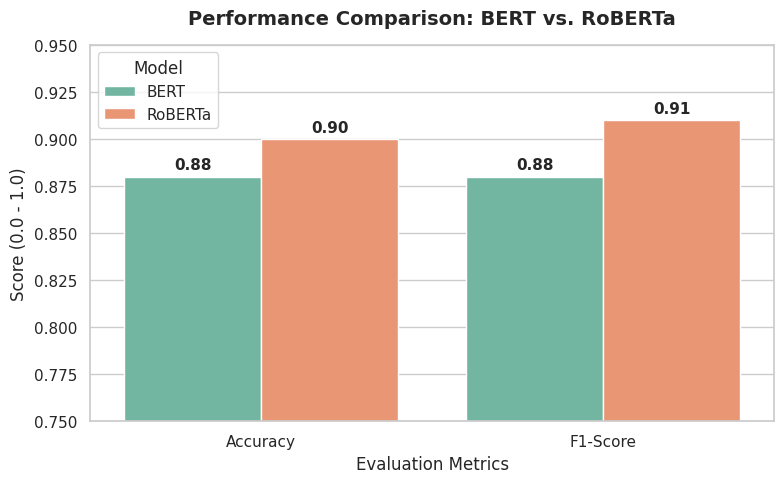

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


data = {
    'Model': ['BERT', 'BERT', 'RoBERTa', 'RoBERTa'],
    'Metric': ['Accuracy', 'F1-Score', 'Accuracy', 'F1-Score'],
    'Value': [0.88, 0.88, 0.90, 0.91]
}
df = pd.DataFrame(data)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create the barplot
ax = sns.barplot(x='Metric', y='Value', hue='Model', data=df, palette='Set2')


plt.title('Performance Comparison: BERT vs. RoBERTa', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylim(0.75, 0.95)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}',
                    xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()


plt.savefig('model_comparison.png', dpi=300)
plt.show()

Creating a gradio interface for better usuability

In [ ]:

!pip install -q gradio

import gradio as gr
import torch
import torch.nn.functional as F


def predict_review_ui(review_text, model_choice):
    if not review_text.strip():
        return "Please enter some text to test!"

    # Decide which tokenizer and model to use based on the dropdown choice
    if model_choice == "BERT (88% Accuracy)":
        selected_model = model
        selected_tokenizer = tokenizer
    else:
        selected_model = roberta_model
        selected_tokenizer = roberta_tokenizer

    # Set selected model to eval mode
    selected_model.eval()


    inputs = selected_tokenizer(
        review_text,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    ).to(device)


    with torch.no_grad():
        outputs = selected_model(**inputs)

    logits = outputs.logits


    probabilities = F.softmax(logits, dim=-1).squeeze().tolist()


    return {
        "Verified REAL / TRUTHFUL": probabilities[0],
        "🚨 ALERT: DECEPTIVE / FAKE": probabilities[1]
    }

# Designing the Frontend Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🔍 AI-Powered Fake Review Identification System")
    gr.Markdown(
        "This system leverages state-of-the-art Transformer models fine-tuned on the "
        "*Deceptive Opinion Spam Corpus* to detect fraudulent hotel reviews based on contextual linguistic patterns."
    )

    with gr.Row():

        with gr.Column(scale=2):
            input_text = gr.Textbox(
                lines=6,
                label="Step 1: Paste or Type Your Review",
                placeholder="Ex: The room was okay, but the service was terrible..."
            )
            model_dropdown = gr.Dropdown(
                choices=["BERT (88% Accuracy)", "RoBERTa (90% Accuracy)"],
                value="RoBERTa (90% Accuracy)",
                label="Step 2: Choose Classification Model"
            )
            submit_btn = gr.Button("Analyze Review", variant="primary")


        with gr.Column(scale=1):
            output_label = gr.Label(num_top_classes=2, label="Analysis Result")


    gr.Examples(
        examples=[
            ["We stayed here for 2 nights. The location is perfect, right next to the metro. The bathroom fan was incredibly loud though, which made it hard to sleep.", "RoBERTa (90% Accuracy)"],
            ["This hotel is absolute perfection! The luxury is unmatched, the staff are literal royalty, and every moment was a magical dream. Book now!", "RoBERTa (90% Accuracy)"]
        ],
        inputs=[input_text, model_dropdown]
    )


    submit_btn.click(fn=predict_review_ui, inputs=[input_text, model_dropdown], outputs=output_label)


demo.launch(debug=True)

/tmp/ipykernel_855/411832854.py:49: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://631b6bc7ce512b2458.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
